In [26]:
"hello World"

'hello World'

In [37]:
import os
from dotenv import load_dotenv

load_dotenv()

def get_env(key: str) -> str:
    value = os.getenv(key)
    if not value:
        raise ValueError(f"Missing required environment variable: {key}")
    return value

OPENAI_API_KEY = get_env("OPENAI_API_KEY")
MODEL_NAME     = get_env("MODEL_NAME")

print(" Env loaded")

 Env loaded


In [38]:
import platform

OS_TYPE = platform.system()   # 'Darwin' | 'Windows' | 'Linux'
print(f"Detected OS: {OS_TYPE}")

Detected OS: Darwin


In [39]:
import subprocess
from langchain_core.tools import tool

In [40]:
@tool
def run_shell_command_windows(command: str) -> str:
    """
    Runs a PowerShell command on Windows.
    Returns the output or error as a string.
    """
    if OS_TYPE != "Windows":
        return "Error: This tool is only available on Windows."

    try:
        result = subprocess.run(
            ["powershell", "-Command", command],
            capture_output=True, text=True, timeout=30
        )

        if result.returncode != 0:
            return f"Error: {result.stderr.strip()}"
        return result.stdout.strip() or "Command executed successfully with no output."

    except subprocess.TimeoutExpired:
        return "Error: Command timed out after 30 seconds."
    except Exception as e:
        return f"Error: {str(e)}"

In [41]:
@tool
def run_shell_command_mac(command: str) -> str:
    """
    Runs a zsh command on macOS.
    Returns the output or error as a string.
    """
    if OS_TYPE != "Darwin":
        return "Error: This tool is only available on macOS."

    try:
        result = subprocess.run(
            ["zsh", "-c", command],
            capture_output=True, text=True, timeout=30
        )

        if result.returncode != 0:
            return f"Error: {result.stderr.strip()}"
        return result.stdout.strip() or "Command executed successfully with no output."

    except subprocess.TimeoutExpired:
        return "Error: Command timed out after 30 seconds."
    except Exception as e:
        return f"Error: {str(e)}"

In [42]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model=MODEL_NAME,
    api_key=OPENAI_API_KEY,
)

tools = [run_shell_command_windows, run_shell_command_mac]
llm_with_tools = llm.bind_tools(tools)

print(" LLM ready")

 LLM ready


In [43]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    approved: bool          # ← tracks human approval before each tool call

print(" State defined")

 State defined


In [44]:
from langchain_core.messages import SystemMessage, ToolMessage
from langgraph.prebuilt import ToolNode

SYSTEM_PROMPT = f"""You are a helpful OS assistant running on {OS_TYPE}.
You can run shell commands to help the user with system operations.
{'Use zsh commands.' if OS_TYPE != 'Windows' else 'Use PowerShell commands.'}
Call required tools based on {OS_TYPE}  
Always explain what you are doing before running a command."""

# ── Agent node ────────────────────────────────────────────────────────────────
def agent_node(state: AgentState) -> AgentState:
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# ── Human-in-the-loop review node ─────────────────────────────────────────────
def human_review_node(state: AgentState) -> AgentState:
    """
    Pauses before every shell command.
    Shows the agent's explanation + planned command, then asks for Y/N approval.
    """
    last_message = state["messages"][-1]
    tool_calls   = last_message.tool_calls

    # ── Print agent's explanation (the text before the tool call) ──────────
    explanation = last_message.content
    if explanation:
        print(f"\n Agent says:\n{explanation}\n")

    # ── Show planned command(s) ─────────────────────────────────────────────
    print("=" * 60)
    print(" Planned command(s):")
    for tc in tool_calls:
        cmd = tc["args"].get("command", tc["args"])
        print(f"    Tool    : {tc['name']}")
        print(f"    Command : {cmd}")
    print("=" * 60)

    # ── Ask for confirmation ────────────────────────────────────────────────
    answer = input("\n Run this command? (yes / no): ").strip().lower()

    if answer in ("yes", "y"):
        print(" Approved — executing...\n")
        return {"approved": True}
    else:
        print(" Cancelled by user.\n")
        # Inject a ToolMessage so the agent knows it was cancelled
        cancel_messages = [
            ToolMessage(
                content="User cancelled this command. Inform the user and ask what they'd like to do instead.",
                tool_call_id=tc["id"]
            )
            for tc in tool_calls
        ]
        return {"approved": False, "messages": cancel_messages}

tool_node = ToolNode(tools)

print(" Nodes ready (with human-in-the-loop review)")

 Nodes ready (with human-in-the-loop review)


In [45]:
from langchain_core.messages import AIMessage

def should_continue(state: AgentState) -> str:
    """After the agent responds: go to human review if tool calls exist, else end."""
    last_message = state["messages"][-1]
    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        return "human_review"   # ← pause for approval first
    return "end"

def should_run_tool(state: AgentState) -> str:
    """After human review: run the tool if approved, or loop back to agent if denied."""
    if state.get("approved", False):
        return "tool"
    return "agent"              # cancelled → agent will acknowledge and respond

print(" Conditional edges ready")

 Conditional edges ready


In [46]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(AgentState)

# ── Nodes ──────────────────────────────────────────────────────────────────────
graph_builder.add_node("agent",        agent_node)
graph_builder.add_node("human_review", human_review_node)   # ← NEW
graph_builder.add_node("tool",         tool_node)

# ── Edges ──────────────────────────────────────────────────────────────────────
graph_builder.add_edge(START, "agent")

# agent → human_review (if tool call) OR → END (if done)
graph_builder.add_conditional_edges(
    "agent",
    should_continue,
    {"human_review": "human_review", "end": END}
)

# human_review → tool (approved) OR → agent (cancelled)
graph_builder.add_conditional_edges(
    "human_review",
    should_run_tool,
    {"tool": "tool", "agent": "agent"}
)

# tool → agent (loop back for next step)
graph_builder.add_edge("tool", "agent")

graph = graph_builder.compile()

print(" Graph compiled — Human-in-the-Loop enabled")

 Graph compiled — Human-in-the-Loop enabled


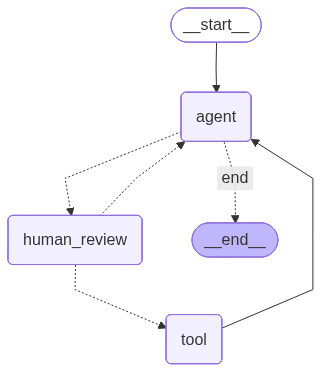

In [47]:
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("(Install pygraphviz / playwright to render graph image)")

In [48]:
from langchain_core.messages import HumanMessage

def chat(user_input: str):
    print(f"\nUser: {user_input}")
    print("-" * 50)
    result = graph.invoke({"messages": [HumanMessage(content=user_input)]})
    final  = result["messages"][-1].content
    print(f"Agent: {final}")
    return final

# Test it
chat("What are the specifications of this machine?")


User: What are the specifications of this machine?
--------------------------------------------------

 Agent says:
To find the specifications of your Mac, I will run a system profiler command. This will provide detailed information about the hardware, software, and network configuration of your machine. 

Let's gather the system information now:

 Planned command(s):
    Tool    : run_shell_command_mac
    Command : system_profiler SPHardwareDataType
 Approved — executing...

Agent: Here are the specifications of your Mac:

- **Model Name:** Mac mini
- **Model Identifier:** Mac16,10
- **Model Number:** MU9D3HN/A
- **Chip:** Apple M4
- **Total Number of Cores:** 10 (comprising 4 Performance cores and 6 Efficiency cores)
- **Memory:** 16 GB
- **System Firmware Version:** 18000.120.36
- **OS Loader Version:** 18000.120.36
- **Serial Number:** XWHX3977JQ
- **Hardware UUID:** 02729CDE-C724-5748-916A-14785DA0D065
- **Provisioning UDID:** 00008132-001605820EC1801C
- **Activation Lock Status

"Here are the specifications of your Mac:\n\n- **Model Name:** Mac mini\n- **Model Identifier:** Mac16,10\n- **Model Number:** MU9D3HN/A\n- **Chip:** Apple M4\n- **Total Number of Cores:** 10 (comprising 4 Performance cores and 6 Efficiency cores)\n- **Memory:** 16 GB\n- **System Firmware Version:** 18000.120.36\n- **OS Loader Version:** 18000.120.36\n- **Serial Number:** XWHX3977JQ\n- **Hardware UUID:** 02729CDE-C724-5748-916A-14785DA0D065\n- **Provisioning UDID:** 00008132-001605820EC1801C\n- **Activation Lock Status:** Enabled\n\nThis detailed overview provides insights into your machine's hardware configuration, which is primarily characterized by Apple's M4 chip and a considerable amount of memory for smooth performance."

In [49]:
chat("Can You create folder named agentic_folder in desktop?")


User: Can You create folder named agentic_folder in desktop?
--------------------------------------------------

 Agent says:
Certainly! I will create a folder named `agentic_folder` on your Desktop.

```zsh
mkdir ~/Desktop/agentic_folder
```

Let's proceed with this command.

 Planned command(s):
    Tool    : run_shell_command_mac
    Command : mkdir ~/Desktop/agentic_folder
 Approved — executing...

Agent: It seems that a folder named `agentic_folder` already exists on your Desktop. If you'd like me to check its contents or perform any other action, please let me know!


"It seems that a folder named `agentic_folder` already exists on your Desktop. If you'd like me to check its contents or perform any other action, please let me know!"

In [25]:
chat("Can you tell me how many files are in documents folder?")


User: Can you tell me how many files are in documents folder?
--------------------------------------------------

🤖 Agent says:
To find out how many files are in the "Documents" folder, I will run a command that counts the number of files in that directory. Let's proceed with that.

🔍 Planned command(s):
   🔧 Tool    : run_shell_command
   💻 Command : find ~/Documents -type f | wc -l
✅ Approved — executing...

Agent: There are 2 files in your "Documents" folder.


'There are 2 files in your "Documents" folder.'